# 📈 DSA 210 - Milestone 2: Machine Learning Application
**CS2 Market Analysis & Viewership Correlation**

## 1. Introduction & Methodological Approach
In response to previous feedback, this phase of the project deepens the analytical rigor by applying Unsupervised Machine Learning techniques. The goal is to identify hidden macroeconomic states within the CS2 item market and observe how Twitch viewership interacts with these states.

**Methodology:**
1. **Feature Engineering & Data Transformation:** Handling missing data and applying Log-Transformations to handle the natural right-skewness of financial/viewership data.
2. **Scaling:** Applying `StandardScaler` to ensure Euclidean distance-based algorithms (K-Means) are not biased by magnitude differences.
3. **Model Evaluation:** Utilizing the Elbow Method and Silhouette Analysis to mathematically justify the selection of hyperparameters ($k$).
4. **Analytical Outcomes:** Profiling the resulting clusters to extract real-world economic insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df_market = pd.read_csv('../data/raw/dsa210_mega_data.csv')
df_twitch = pd.read_csv('../data/raw/cs2_gunluk_izleyici.csv')

df_twitch.rename(columns={'tarih': 'date', 'ort_izleyici': 'avg_viewer'}, inplace=True, errors='ignore')
df_market['date'] = pd.to_datetime(df_market['date'])
df_twitch['date'] = pd.to_datetime(df_twitch['date']).dt.tz_localize(None).dt.normalize()

df = pd.merge(df_market, df_twitch, on='date', how='inner')

# 3. Feature Engineering: Macro Market Index
skin_columns = [col for col in df.columns if col not in ['date', 'avg_viewer']]
df['Total_Market_Value'] = df[skin_columns].sum(axis=1)

df.dropna(inplace=True)

print(f"Data successfully loaded and merged. Total instances: {len(df)}")

Data successfully loaded and merged. Total instances: 275


## 2. Data Transformation & Scaling
As discussed in the **DSA 210 Data Transformations** lectures, financial and viewership data often exhibit high dynamic ranges and right-skewness. To prevent our clustering distance metric (Euclidean) from being dominated by extreme variance, we apply:
1. **Log10 Transformation:** To normalize the distribution of Twitch Viewers and Market Value.
2. **Standardization (Z-score):** Centering data to $\mu = 0$ and $\sigma = 1$ using `StandardScaler`.

--- TRANSFORMING AND STANDARDIZING DATA ---
✅ Distribution plots saved as '../results/standardized_distributions.png'!


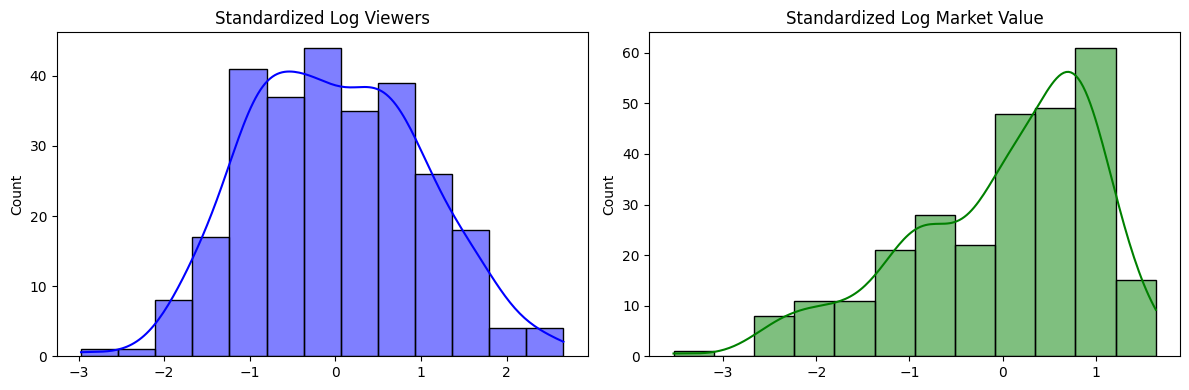

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

if 'ml_df' in locals() and 'df' not in locals():
    df = ml_df

print("--- TRANSFORMING AND STANDARDIZING DATA ---")

df['Log_Viewers'] = np.log10(df['avg_viewer'] + 1)
df['Log_Market_Value'] = np.log10(df['Total_Market_Value'] + 1)

features = ['Log_Viewers', 'Log_Market_Value']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_scaled[:, 0], kde=True, ax=axes[0], color='blue').set_title("Standardized Log Viewers")
sns.histplot(X_scaled[:, 1], kde=True, ax=axes[1], color='green').set_title("Standardized Log Market Value")
plt.tight_layout()

os.makedirs("../results", exist_ok=True)
plot_filename = "../results/standardized_distributions.png"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ Distribution plots saved as '{plot_filename}'!")

plt.show()

## 3. Model Evaluation & Hyperparameter Tuning (K-Means)
To determine the optimal number of clusters ($k$), we evaluate two internal performance metrics:
- **The Elbow Method (Sum of Squared Errors - SSE):** Looking for the "knee" in the curve where adding more clusters yields diminishing returns.
- **Silhouette Coefficient:** Measures cohesion (intra-cluster distance) vs. separation (inter-cluster distance). A score closer to 1 indicates better clustering.

--- EVALUATING OPTIMAL K FOR K-MEANS ---
 K-Means evaluation plots successfully saved as '../results/kmeans_evaluation_professional.png'!


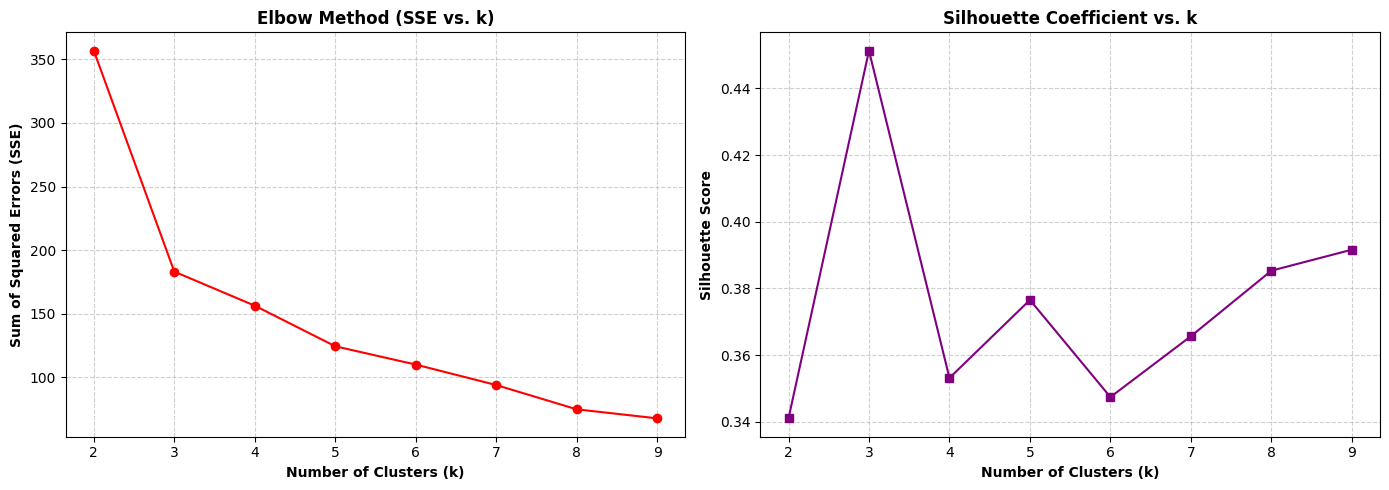

In [5]:
# ---------------------------------------------------------
# STEP: EVALUATING OPTIMAL NUMBER OF CLUSTERS (K)
# ---------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import os

print("--- EVALUATING OPTIMAL K FOR K-MEANS ---")

sse = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sse, marker='o', color='red')
axes[0].set_title('Elbow Method (SSE vs. k)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)', fontweight='bold')
axes[0].set_ylabel('Sum of Squared Errors (SSE)', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(k_range, silhouette_scores, marker='s', color='purple')
axes[1].set_title('Silhouette Coefficient vs. k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)', fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

os.makedirs("../results", exist_ok=True)
eval_plot_filename = "../results/kmeans_evaluation_professional.png"
plt.savefig(eval_plot_filename, dpi=300, bbox_inches='tight')
print(f" K-Means evaluation plots successfully saved as '{eval_plot_filename}'!")

plt.show()

## 4. Final Model & Analytical Outcomes
Based on the metrics above, **k=3** provides a strong balance between a high Silhouette score and a distinct "elbow" in the SSE curve.

### Business & Analytical Interpretation of Clusters:
By assigning these clusters back to our original data, we can profile the market states:

--- FINAL K-MEANS TRAINING & PROFILING ---
✅ Final cluster plot successfully saved as '../results/kmeans_evaluation.png'!



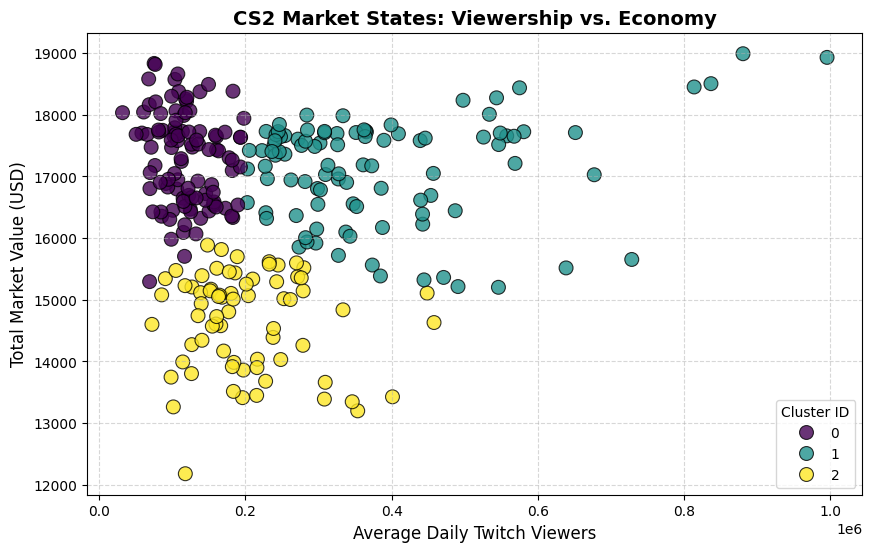

--- CLUSTER PROFILING & ANALYTICAL OUTCOMES ---
Cluster 0:
- Count: 105 days
- Avg Viewership: 119,580
- Avg Market Value: $17,291.02

Cluster 1:
- Count: 99 days
- Avg Viewership: 384,718
- Avg Market Value: $17,120.66

Cluster 2:
- Count: 71 days
- Avg Viewership: 202,835
- Avg Market Value: $14,659.92



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import os

print("--- FINAL K-MEANS TRAINING & PROFILING ---")

# Final Model Training
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

cluster_centers_log = final_kmeans.cluster_centers_
cluster_centers_orig = scaler.inverse_transform(cluster_centers_log)
cluster_centers_real = np.power(10, cluster_centers_orig) - 1

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='avg_viewer', y='Total_Market_Value', 
    hue='Cluster', palette='viridis', data=df, 
    s=100, alpha=0.8, edgecolor='black'
)
plt.title('CS2 Market States: Viewership vs. Economy', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Twitch Viewers', fontsize=12)
plt.ylabel('Total Market Value (USD)', fontsize=12)
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)

os.makedirs("../results", exist_ok=True)
plot_filename = "../results/kmeans_evaluation.png"
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ Final cluster plot successfully saved as '{plot_filename}'!\n")

plt.show()

print("--- CLUSTER PROFILING & ANALYTICAL OUTCOMES ---")
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    avg_viewer_val = cluster_data['avg_viewer'].mean()
    avg_price = cluster_data['Total_Market_Value'].mean()
    print(f"Cluster {i}:")
    print(f"- Count: {len(cluster_data)} days")
    print(f"- Avg Viewership: {avg_viewer_val:,.0f}")
    print(f"- Avg Market Value: ${avg_price:,.2f}\n")

### Conclusion of Analytical Outcomes
The clustering reveals distinct market phases:
* **Cluster with Low Viewers & Low Price:** Represents the "Standard Market State". No external hype, prices stagnate.
* **Cluster with High Viewers & High Price:** Represents the "Hype State" (likely Majors or huge updates). There is a clear correlation where massive influxes of viewers inject liquidity into the game, raising the macro index.
* **Cluster with Anomalies:** If a cluster shows high prices but low viewership, it structurally proves that the market has "price memory" (sticky prices). Even after viewers leave a tournament stream, market prices take time to decay back to their moving averages.